# SWAP-Stress: 9 km CONUS Feature Rasters (EASE-Grid2)

This notebook provides a visual tour of all static covariate rasters used for
CONUS-scale soil hydraulic parameter inference.

All rasters have been exported from Google Earth Engine at ~9 km resolution and
reprojected to EASE-Grid2 (EPSG:6933) to align pixel-for-pixel with SMAP L3
daily soil moisture GeoTIFFs.

This notebook covers:
1. Inventory of all feature rasters (file, band count, shape)
2. Representative band maps for each of the 11 feature groups
3. Summary of total band count across all groups

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception:
    rasterio = None

try:
    import geopandas as gpd
except Exception:
    gpd = None

# -----------------------------
# Config
# -----------------------------
DATA_ROOT = os.environ.get("SWAPSTRESS_DATA_ROOT", "/nas/soils")
DATA_ROOT = str(Path(DATA_ROOT).expanduser())

FEAT_DIR = os.path.join(DATA_ROOT, "swapstress", "inference", "conus_features")
US_STATES_SHP = "/nas/boundaries/us_states_tiger_wgs.shp"

OUT_DIR = Path("notebooks/_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load US state boundaries once (reprojected to EASE-Grid2)
states = None
if gpd is not None and os.path.exists(US_STATES_SHP):
    states = gpd.read_file(US_STATES_SHP).to_crs(epsg=6933)

print("FEAT_DIR:", FEAT_DIR)
print("EASE2 files:", len([f for f in os.listdir(FEAT_DIR) if f.endswith("_ease2.tif")]))

FEAT_DIR: /nas/soils/swapstress/inference/conus_features
EASE2 files: 11
FEAT_DIR: /nas/soils/swapstress/inference/conus_features
EASE2 files: 11


## 1) Feature Raster Inventory

Eleven feature groups exported from Google Earth Engine at ~9 km, reprojected to
EASE-Grid2 (EPSG:6933) to align with SMAP L3. Total of ~180 bands covering soil
properties, climate normals, terrain, vegetation indices, land cover, and radar
backscatter.

In [2]:
assert rasterio is not None, "rasterio is required"

rows = []
for f in sorted(os.listdir(FEAT_DIR)):
    if not f.endswith("_ease2.tif"):
        continue
    with rasterio.open(os.path.join(FEAT_DIR, f)) as src:
        descs = [src.descriptions[i] or f"band_{i+1}" for i in range(src.count)]
        rows.append({
            "file": f,
            "bands": src.count,
            "shape": f"{src.width}x{src.height}",
            "dtype": str(src.dtypes[0]),
            "crs": str(src.crs),
            "band_names": ", ".join(descs[:5]) + ("..." if src.count > 5 else ""),
        })

inv_df = pd.DataFrame(rows)
print(f"Total files: {len(inv_df)}")
print(f"Total bands: {inv_df['bands'].sum()}")
print()
inv_df

Total files: 11
Total bands: 180



,file,bands,shape,dtype,crs,band_names
0,fao_hwsd_ease2.tif,15,634x295,float32,EPSG:6933,"HWSD2_ID, WISE30s_ID, COVERAGE, SHARE, WRB4..."
1,landcover_ease2.tif,7,634x295,float32,EPSG:6933,"gsw, c3s_lccs_class_mode, glc10_lc, nlcd, cdl_..."
2,landsat_bands_ease2.tif,70,634x295,float32,EPSG:6933,"B2_mean_gs, B2_stdDev_gs, B3_mean_gs, B3_stdDe..."
3,polaris_ease2.tif,13,634x295,float32,EPSG:6933,"bd_mean, clay_mean, ksat_mean, n_mean, om_mean..."
4,prism_normals_ease2.tif,11,634x295,float32,EPSG:6933,"ppt, tmean, tmin, tmax, tdmean..."
5,sentinel1_ease2.tif,6,634x295,float32,EPSG:6933,"VV_mean, VH_mean, VH_VV_mean, VV_stdDev, VH_st..."
6,smap_l3_clim_ease2.tif,4,634x295,float32,EPSG:6933,"vegetation_water_content_am_mean, vegetation_w..."
7,soilgrids_ease2.tif,20,634x295,float32,EPSG:6933,"bdod_0-5cm_mean, bdod_5-15cm_mean, cec_0-5cm_m..."
8,ssurgo_ease2.tif,4,634x295,float32,EPSG:6933,"ssurgo_awc, ssurgo_clay, ssurgo_ksat, ssurgo_sand"
9,terrain_ease2.tif,8,634x295,float32,EPSG:6933,"elevation, slope, aspect, tpi_10000, tpi_22500..."


In [3]:
def plot_bands(tif_path, band_names, ncols=2, cmap="viridis", title=None):
    """Plot selected bands from a multi-band GeoTIFF as a grid of maps."""
    with rasterio.open(tif_path) as src:
        descs = [src.descriptions[i] or f"band_{i+1}" for i in range(src.count)]
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

        indices = []
        for name in band_names:
            if name in descs:
                indices.append(descs.index(name))
            else:
                print(f"  Warning: '{name}' not found in {os.path.basename(tif_path)}")
                print(f"  Available: {descs}")

        if not indices:
            return None

        bands = [src.read(i + 1) for i in indices]

    n = len(indices)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flat

    for i, (arr, idx) in enumerate(zip(bands, indices)):
        ax = axes[i]
        valid = arr[~np.isnan(arr)]
        if len(valid):
            vmin, vmax = np.percentile(valid, [2, 98])
        else:
            vmin, vmax = 0, 1

        im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)
        if states is not None:
            states.boundary.plot(ax=ax, color="0.3", linewidth=0.3)
        # Clip to raster bounds (already a CONUS subset)
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
        ax.set_title(descs[idx], fontsize=10)
        ax.tick_params(labelsize=7)

    for j in range(n, nrows * ncols):
        axes[j].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=13, y=1.01)
    fig.tight_layout()
    return fig

print("plot_bands helper defined")

plot_bands helper defined


### 2a) SoilGrids (ISRIC, 250 m native)

SoilGrids v2.0 provides global predictions of soil properties at 250 m resolution
using machine learning on ~240k soil profiles. We include two depth intervals
(0–5 cm and 5–15 cm) for 10 properties: bulk density, CEC, coarse fragments,
clay, sand, silt, nitrogen, pH, SOC, and organic carbon density (20 bands total).

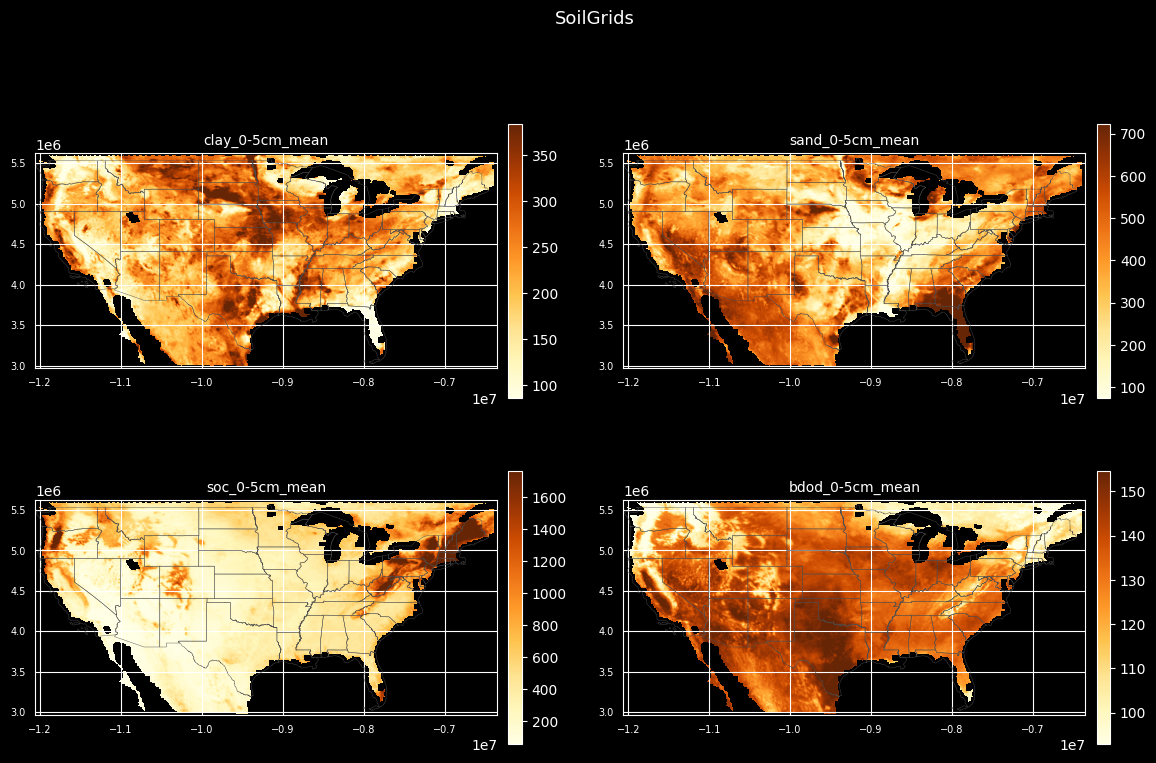

In [4]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "soilgrids_ease2.tif"),
    ['clay_0-5cm_mean', 'sand_0-5cm_mean', 'soc_0-5cm_mean', 'bdod_0-5cm_mean'],
    ncols=2,
    cmap="YlOrBr",
    title="SoilGrids",
)
plt.show()

### 2b) WorldClim Bioclimatic + Reference ETo (1 km native)

WorldClim v2.1 long-term climate normals (1970–2000) averaged to seasonal means
(winter/spring/summer/autumn): precipitation, tavg, tmin, tmax. Combined with
MODIS-based reference evapotranspiration (ETo) seasonal means and annual
statistics (22 bands).

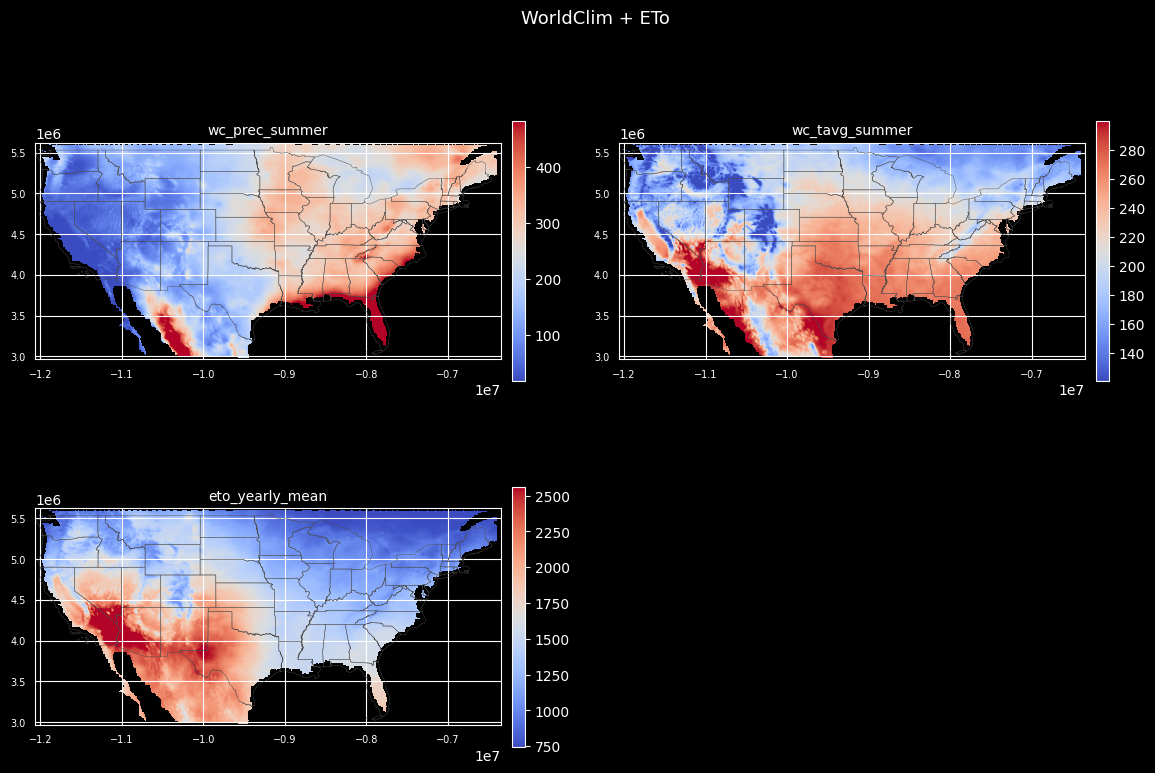

In [5]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "worldclim_ease2.tif"),
    ['wc_prec_summer', 'wc_tavg_summer', 'eto_yearly_mean'],
    ncols=2,
    cmap="coolwarm",
    title="WorldClim + ETo",
)
plt.show()

### 2c) SMAP L3 Vegetation Water Content Climatology (9 km native)

Multi-year mean and standard deviation of SMAP L3 vegetation water content
retrieved alongside soil moisture. Separate AM and PM pass statistics provide a
proxy for canopy water status and vegetation density (4 bands).

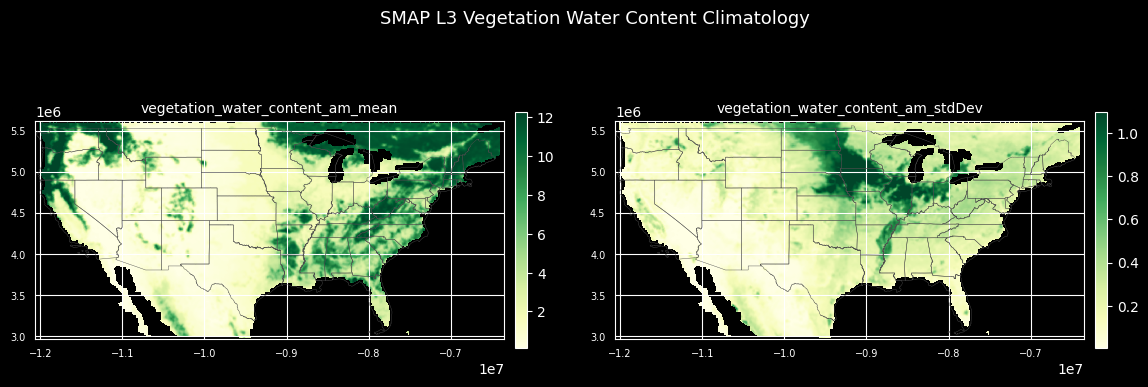

In [6]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "smap_l3_clim_ease2.tif"),
    ['vegetation_water_content_am_mean', 'vegetation_water_content_am_stdDev'],
    ncols=2,
    cmap="YlGn",
    title="SMAP L3 Vegetation Water Content Climatology",
)
plt.show()

### 2d) Terrain (SRTM 30 m native, lithology 1 km)

SRTM-derived elevation, slope, aspect, and topographic position index at two
scales (10 km and 22.5 km neighborhood). Also includes US lithology classification
and a constant band for regression intercept (8 bands).

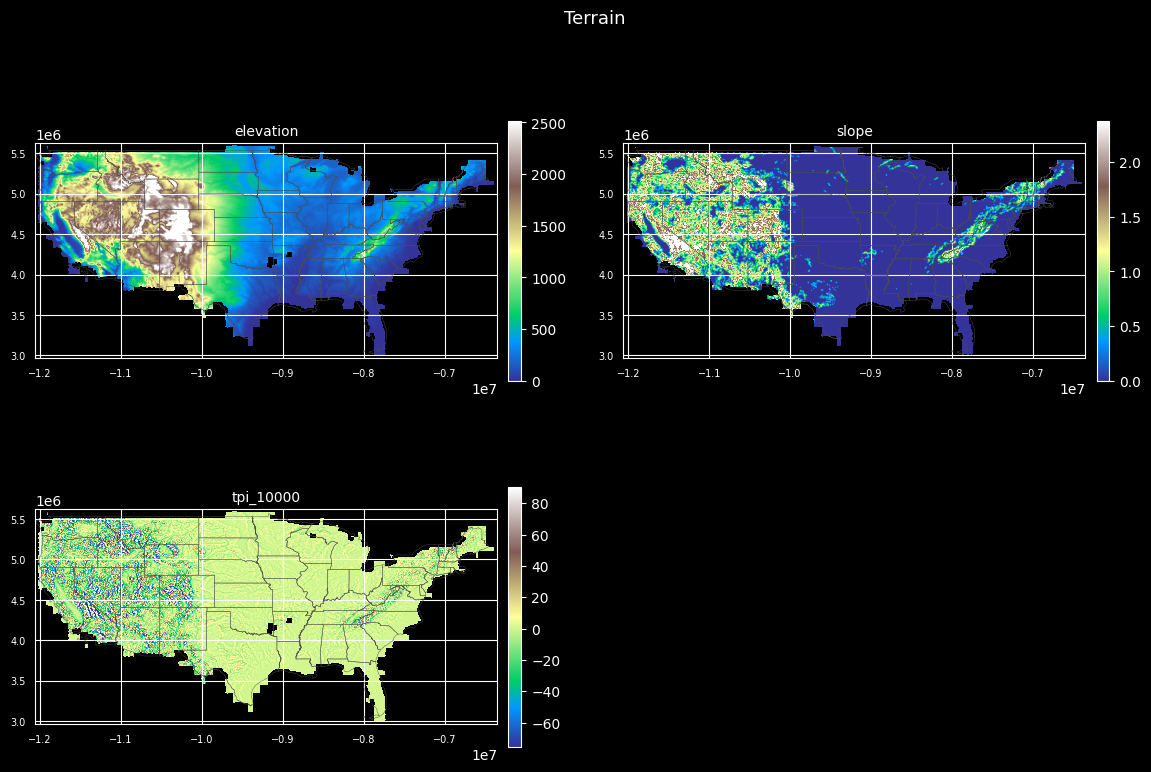

In [7]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "terrain_ease2.tif"),
    ['elevation', 'slope', 'tpi_10000'],
    ncols=2,
    cmap="terrain",
    title="Terrain",
)
plt.show()

### 2e) POLARIS Soil Properties (30 m native, CONUS only)

POLARIS provides probabilistic soil property maps for CONUS derived from SSURGO
and machine learning. Includes texture, bulk density, saturated hydraulic
conductivity, porosity, and Brooks–Corey parameters (13 bands).

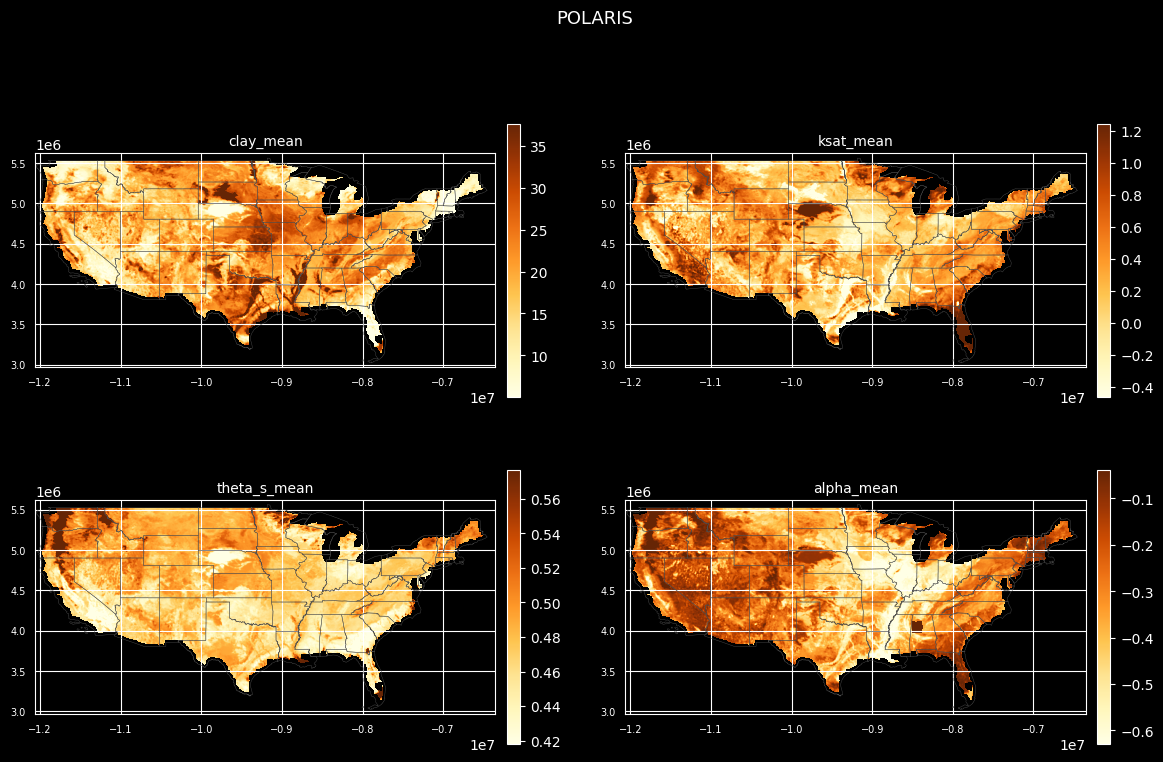

In [8]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "polaris_ease2.tif"),
    ['clay_mean', 'ksat_mean', 'theta_s_mean', 'alpha_mean'],
    ncols=2,
    cmap="YlOrBr",
    title="POLARIS",
)
plt.show()

### 2f) PRISM Climate Normals (800 m native, CONUS only)

PRISM 30-year normals (1991–2020) for precipitation, temperature (mean, min, max),
dew point temperature, VPD (min, max), and solar radiation components. Higher
spatial detail than WorldClim for CONUS (11 bands).

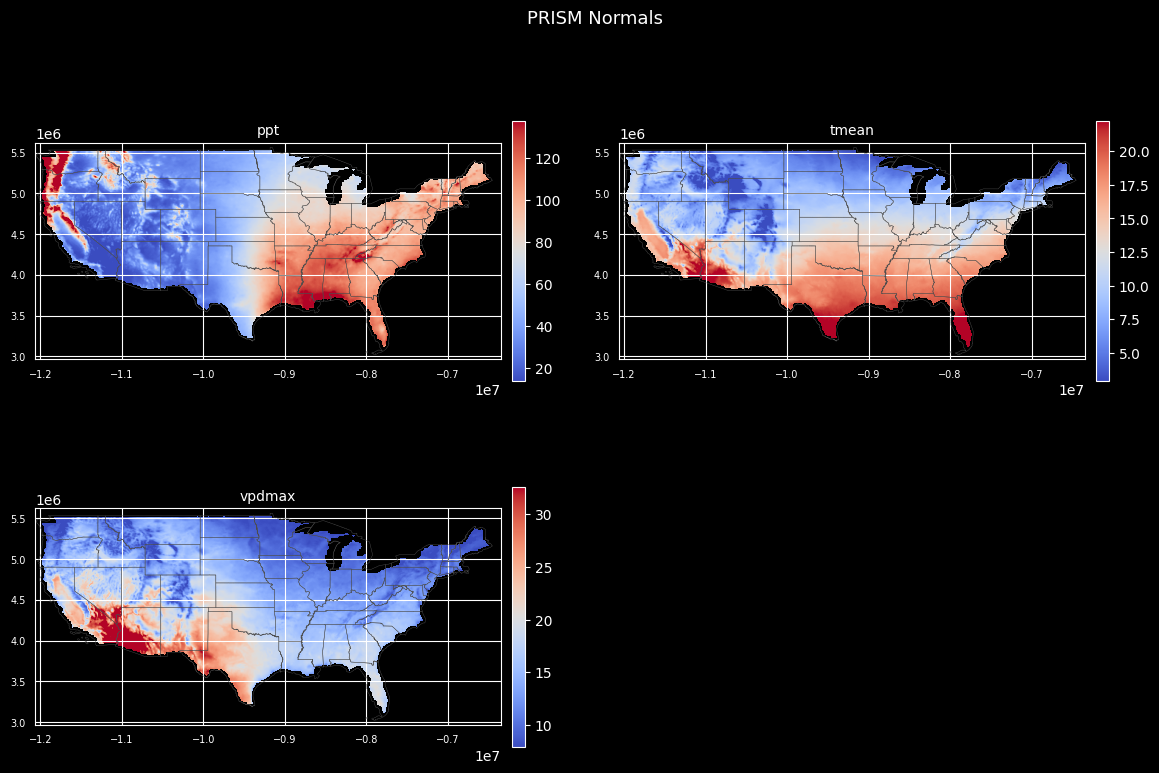

In [9]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "prism_normals_ease2.tif"),
    ['ppt', 'tmean', 'vpdmax'],
    ncols=2,
    cmap="coolwarm",
    title="PRISM Normals",
)
plt.show()

### 2g) SSURGO Soil Survey (variable native, CONUS only)

USDA SSURGO soil survey data aggregated from map-unit polygons: available water
capacity, clay fraction, saturated hydraulic conductivity, and sand fraction.
Survey-based rather than model-predicted (4 bands).

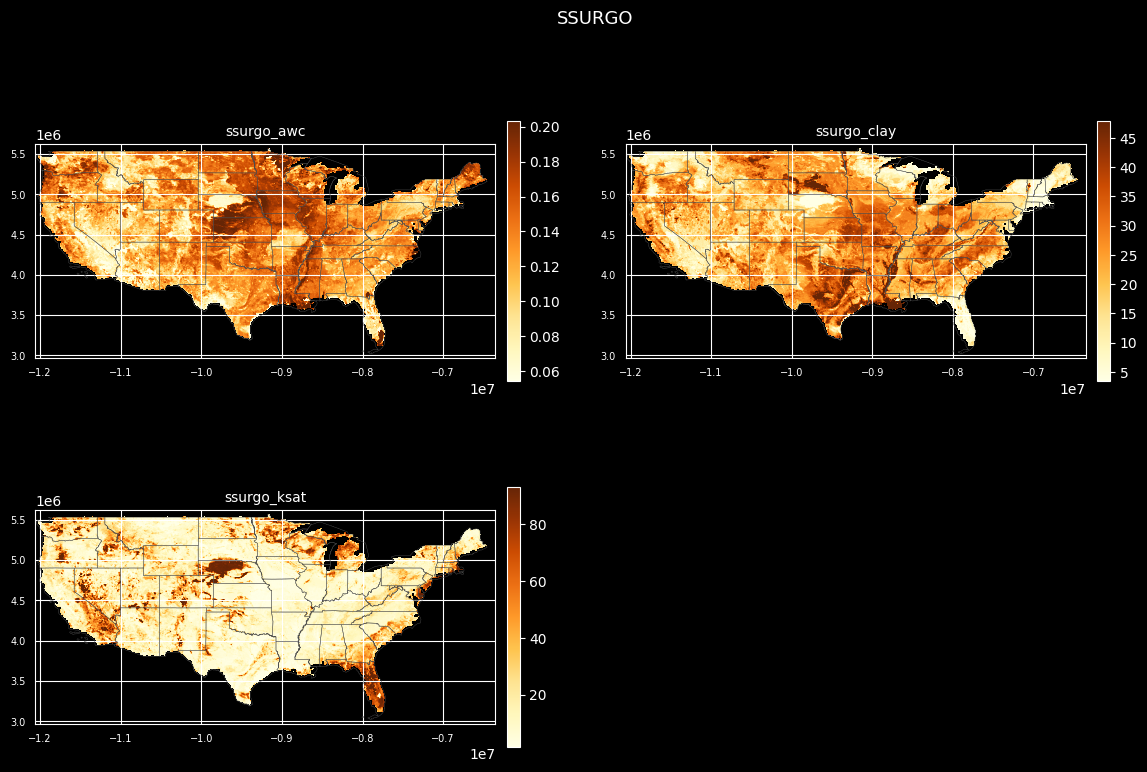

In [10]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "ssurgo_ease2.tif"),
    ['ssurgo_awc', 'ssurgo_clay', 'ssurgo_ksat'],
    ncols=2,
    cmap="YlOrBr",
    title="SSURGO",
)
plt.show()

### 2h) FAO Harmonized World Soil Database (1 km native)

HWSD v2.0 provides global soil properties from national surveys harmonized to a
common schema. Includes classification codes (WRB, FAO90), physical properties
(bulk density, drainage, texture), and derived metrics (AWC, root depth).
Global coverage fills gaps where SSURGO/POLARIS are unavailable (15 bands).

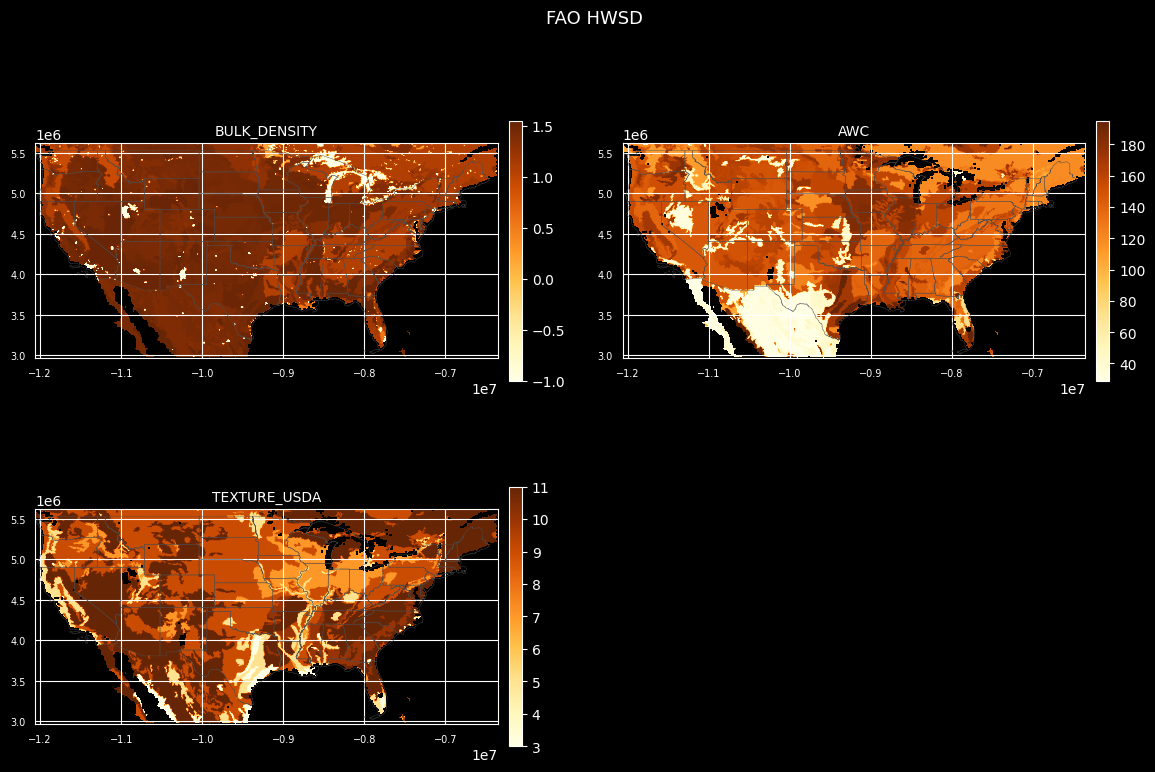

In [11]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "fao_hwsd_ease2.tif"),
    ['BULK_DENSITY', 'AWC', 'TEXTURE_USDA'],
    ncols=2,
    cmap="YlOrBr",
    title="FAO HWSD",
)
plt.show()

### 2i) Land Cover Classifications

Multi-source land cover: NLCD (30 m), USDA Cropland Data Layer (30 m, modal crop
type), C3S Land Cover (300 m, LCCS classes), Global Land Cover 10 m, and JRC
Global Surface Water occurrence. Categorical values using nearest-neighbor
resampling (7 bands).

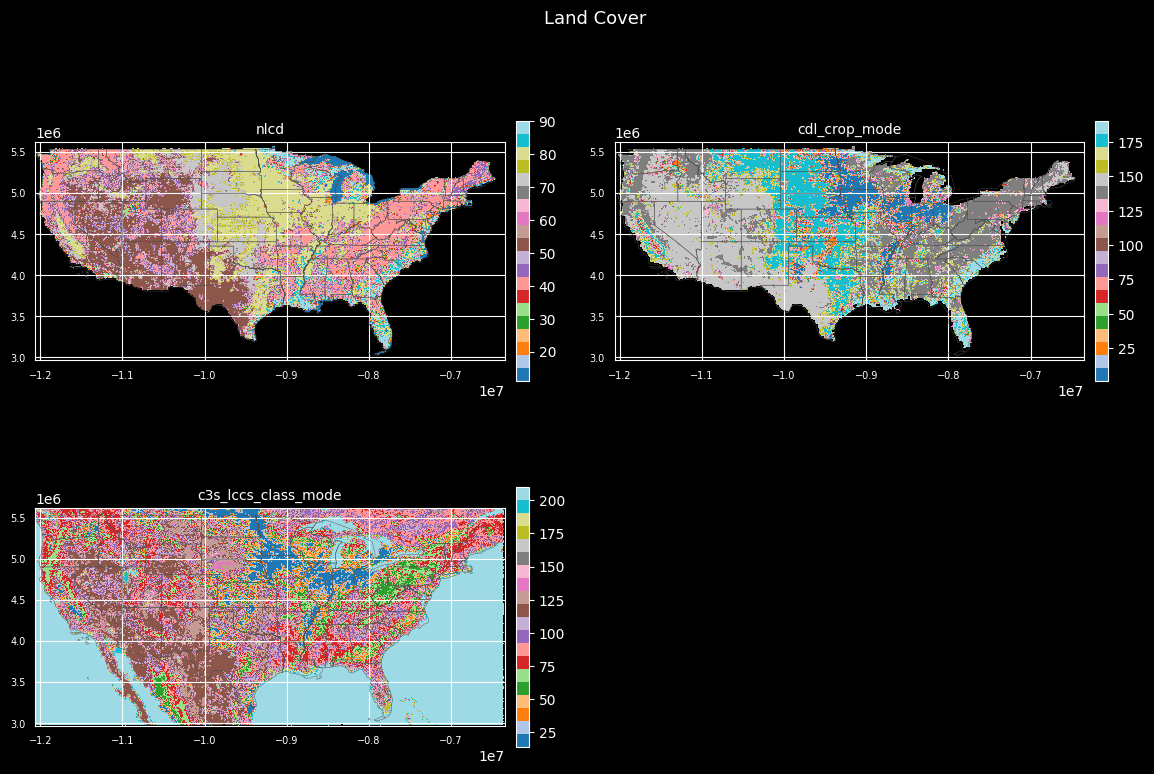

In [16]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "landcover_ease2.tif"),
    ['nlcd', 'cdl_crop_mode', 'c3s_lccs_class_mode'],
    ncols=2,
    cmap="tab20",
    title="Land Cover",
)
plt.show()

### 2j) Landsat 8/9 Spectral Bands (30 m native)

Growing-season and quarterly (Q1–Q4) mean and standard deviation of Landsat 8/9
surface reflectance bands (B2–B7) and thermal brightness temperature (B10).
Captures vegetation phenology and surface energy balance seasonality (70 bands).

In [ ]:
# Compute growing-season NDVI from B5 (NIR) and B4 (Red)
tif_path = os.path.join(FEAT_DIR, "landsat_bands_ease2.tif")
with rasterio.open(tif_path) as src:
    descs = [src.descriptions[i] or f"band_{i+1}" for i in range(src.count)]
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    nir = src.read(descs.index("B5_mean_gs") + 1)
    red = src.read(descs.index("B4_mean_gs") + 1)

denom = nir + red
ndvi = np.where(denom > 0, (nir - red) / denom, np.nan)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(ndvi, extent=extent, origin="upper", cmap="YlGn", vmin=0, vmax=0.8)
if states is not None:
    states.boundary.plot(ax=ax, color="0.3", linewidth=0.3)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label="NDVI")
ax.set_title("Landsat 8/9 Growing-Season NDVI", fontsize=13)
ax.tick_params(labelsize=7)
fig.tight_layout()
plt.show()

### 2k) Sentinel-1 C-band SAR (10 m native)

Mean and standard deviation of Sentinel-1 GRD backscatter in VV and VH
polarizations, plus VH/VV ratio. C-band backscatter is sensitive to surface
roughness, soil moisture, and vegetation structure (6 bands).

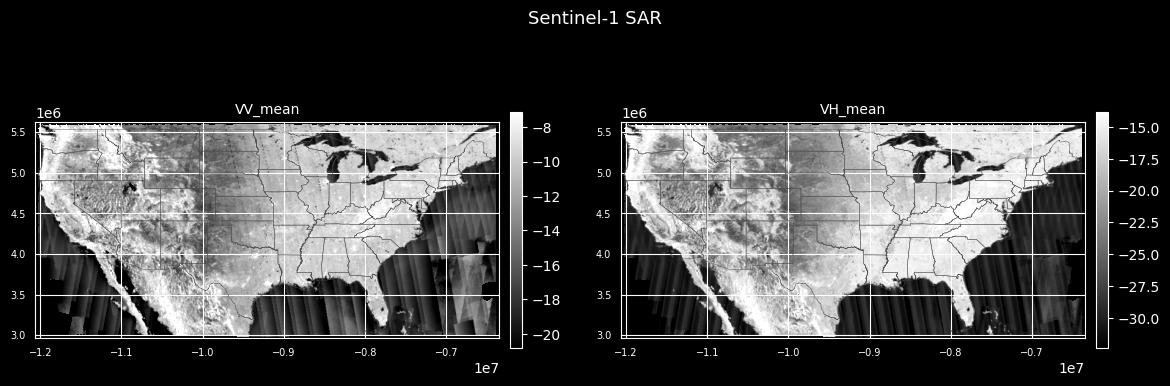

In [14]:
fig = plot_bands(
    os.path.join(FEAT_DIR, "sentinel1_ease2.tif"),
    ['VV_mean', 'VH_mean'],
    ncols=2,
    cmap="gray",
    title="Sentinel-1 SAR",
)
plt.show()

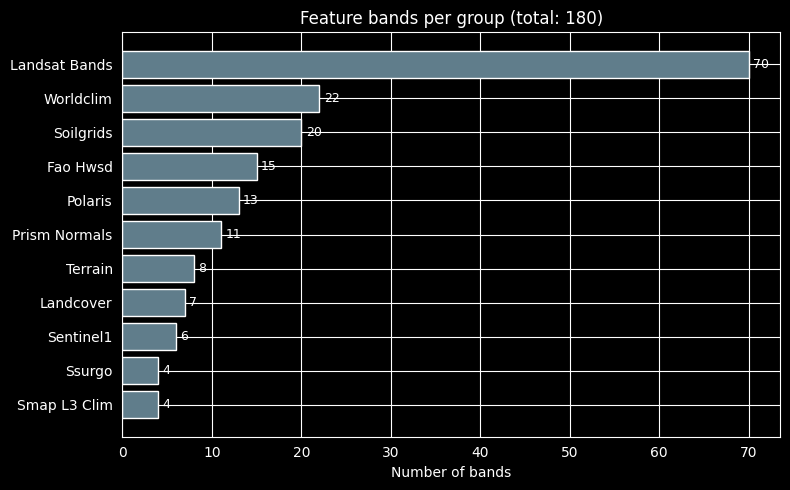

Saved: notebooks/_outputs/9k_feature_band_counts.png


In [15]:
# Band count summary across all feature groups
group_counts = []
for f in sorted(os.listdir(FEAT_DIR)):
    if not f.endswith("_ease2.tif"):
        continue
    with rasterio.open(os.path.join(FEAT_DIR, f)) as src:
        label = f.replace("_ease2.tif", "").replace("_", " ").title()
        group_counts.append({"group": label, "bands": src.count})

gc_df = pd.DataFrame(group_counts).sort_values("bands")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(gc_df["group"], gc_df["bands"], color="#607D8B", edgecolor="white")
for i, (_, row) in enumerate(gc_df.iterrows()):
    ax.text(row["bands"] + 0.5, i, str(row["bands"]), va="center", fontsize=9)

ax.set_xlabel("Number of bands")
ax.set_title(f"Feature bands per group (total: {gc_df['bands'].sum()})")
fig.tight_layout()

out = OUT_DIR / "9k_feature_band_counts.png"
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)